In [1]:
# --- CÉLULA 1: LEITURA LAZY + PREPARO GEO ---

import polars as pl
import geopandas as gpd
from shapely.geometry import Point

csv_path = "/home/labgeo/Documents/base_cartografica/Strikes/adsb_3dep_diff_2025.csv"

lf_raw = pl.scan_csv(csv_path, infer_schema_length=10_000, ignore_errors=True)
cols = set(lf_raw.schema.keys())

rename_map = {
    "TIMESTAMP_": "timestamp_unix",
    "DATETIME_U": "datetime_utc",
    "TIME_DIFF_": "time_diff_sec",
    "CALLSIGN_T": "callsign_traj",
    "PHASE_OF_F": "phase_of_flight",
    "SPECIES_GR": "species_group",
    "geoaltitud": "geoaltitude",
    "baroaltitu": "baroaltitude",
    "lastcontac": "lastcontact",
    "lastposupd": "lastposupdate",
}
rename_map = {k: v for k, v in rename_map.items() if k in cols}

lf = (
    lf_raw.rename(rename_map)
    .with_columns([
        pl.col("STRIKE_ID").cast(pl.Int64, strict=False),
        pl.col("lat").cast(pl.Float64),
        pl.col("lon").cast(pl.Float64),
        pl.col("diff_m").cast(pl.Float64, strict=False),
        pl.col("alt_voo_m").cast(pl.Float64, strict=False),
        pl.col("geoaltitude").cast(pl.Float64, strict=False),
    ])
    .with_columns([
        pl.when(pl.col("alt_voo_m").is_not_null())
          .then(pl.col("alt_voo_m"))
          .otherwise(pl.col("geoaltitude"))
          .alias("z_voo_m")
    ])
)

df = (
    lf.filter(
        pl.col("lat").is_not_null() &
        pl.col("lon").is_not_null() &
        pl.col("diff_m").is_not_null()
    )
    .collect()
)

# Polars -> GeoPandas (WGS84)
df_pd = df.to_pandas()
gdf = gpd.GeoDataFrame(
    df_pd,
    geometry=[Point(xy) for xy in zip(df_pd["lon"], df_pd["lat"])],
    crs="EPSG:4326"
)

gdf.head()


/tmp/ipykernel_3429551/2454125751.py:10: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = set(lf_raw.schema.keys())


,system:index,AIRCRAFT,AIRPORT,AIRPORT_ID,callsign_traj,datetime_utc,FLT,HEIGHT,INCIDENT_D,IS_BIRD,...,lon,onground,serials,spi,time,velocity,vertrate,.geo,z_voo_m,geometry
0,00000000000000000cfc_0,PA-28,GRAND FORKS INTL,KGFK,NDU41,2025/03/24 12:30:00.000,41,500.0,2025/03/24 00:00:00.000,1,...,-97.112480,0,-1408199960,0,2025/03/24 12:29:30.000,59.324116,1.62560,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1158.24,POINT (-97.11248 47.56091)
1,00000000000000000cfd_0,PA-28,GRAND FORKS INTL,KGFK,NDU41,2025/03/24 12:30:00.000,41,500.0,2025/03/24 00:00:00.000,1,...,-97.112595,0,-1408199960,0,2025/03/24 12:29:31.000,59.035670,1.62560,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1158.24,POINT (-97.1126 47.56047)
2,00000000000000000cfe_0,PA-28,GRAND FORKS INTL,KGFK,NDU41,2025/03/24 12:30:00.000,41,500.0,2025/03/24 00:00:00.000,1,...,-97.112820,0,-1408199960,0,2025/03/24 12:29:32.000,58.393360,1.95072,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1158.24,POINT (-97.11282 47.55991)
3,00000000000000000cff_0,PA-28,GRAND FORKS INTL,KGFK,NDU41,2025/03/24 12:30:00.000,41,500.0,2025/03/24 00:00:00.000,1,...,-97.113080,0,-1408199960,0,2025/03/24 12:29:33.000,58.298103,2.27584,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1165.86,POINT (-97.11308 47.55935)
4,00000000000000000d00_0,PA-28,GRAND FORKS INTL,KGFK,NDU41,2025/03/24 12:30:00.000,41,500.0,2025/03/24 00:00:00.000,1,...,-97.113300,0,-1408199960,0,2025/03/24 12:29:34.000,58.248146,1.30048,"{""geodesic"":false,""type"":""Point"",""coordinates""...",1165.86,POINT (-97.1133 47.55884)


/tmp/ipykernel_3429551/3305814042.py:18: DeprecationWarning:

The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.



UTM zone usada: 15 (EPSG:32615)


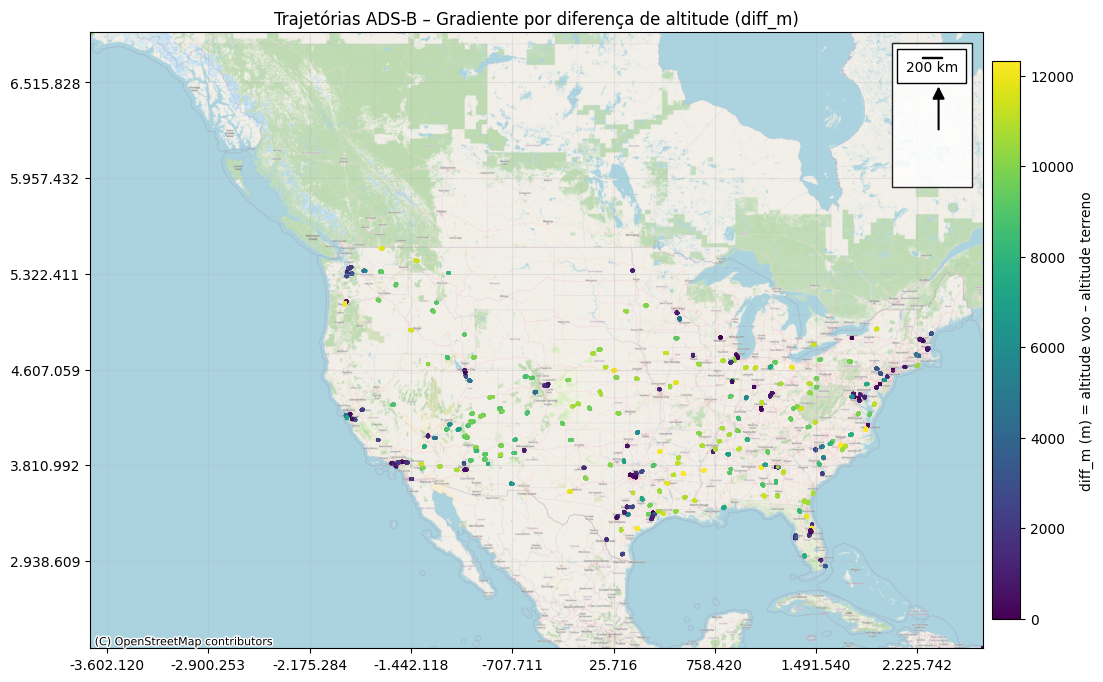

In [13]:
# --- MAPA FINAL: BASEMAP + GRADIENTE diff_m + COORD UTM (só bottom/left) + ESCALA+NORTE no topo direito ---

import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
from matplotlib.colors import Normalize
from pyproj import CRS, Transformer
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib.patches import FancyArrowPatch
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, DrawingArea, TextArea

# 1) Reprojetar para Web Mercator (basemap)
gdf_3857 = gdf.to_crs(epsg=3857)

# 2) Detectar zona UTM pelo centróide em WGS84
gdf_wgs = gdf.to_crs(epsg=4326)
centroid = gdf_wgs.unary_union.centroid
lon0, lat0 = centroid.x, centroid.y
utm_zone = int(np.floor((lon0 + 180) / 6) + 1)
utm_epsg = 32600 + utm_zone if lat0 >= 0 else 32700 + utm_zone
crs_utm = CRS.from_epsg(utm_epsg)

print(f"UTM zone usada: {utm_zone} (EPSG:{utm_epsg})")

to_utm = Transformer.from_crs(3857, crs_utm, always_xy=True)

# 3) Figura
fig, ax = plt.subplots(figsize=(12, 8))

vals = gdf_3857["diff_m"].to_numpy()
norm = Normalize(
    vmin=np.nanpercentile(vals, 2),
    vmax=np.nanpercentile(vals, 98)
)

sc = ax.scatter(
    gdf_3857.geometry.x,
    gdf_3857.geometry.y,
    c=vals,
    s=3,
    norm=norm
)

ax.set_title("Trajetórias ADS-B – Gradiente por diferença de altitude (diff_m)")
ax.grid(True, alpha=0.25)

# sem labels de eixo
ax.set_xlabel("")
ax.set_ylabel("")

# 4) Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=6
)
# Satélite:
# ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=6)

# 5) Colorbar
cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label("diff_m (m) = altitude voo – altitude terreno")

# 6) Limites
xmin, ymin, xmax, ymax = gdf_3857.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# 7) Converter ticks do eixo principal para UTM (só bottom/left)
#    Matplotlib guarda ticks em 3857, mas rotula com UTM.
xmid = (xmin + xmax) / 2
ymid = (ymin + ymax) / 2

def fmt_utm_easting(x, pos=None):
    e, n = to_utm.transform(x, ymid)
    return f"{e:,.0f}".replace(",", ".")  # estilo pt-br com ponto

def fmt_utm_northing(y, pos=None):
    e, n = to_utm.transform(xmid, y)
    return f"{n:,.0f}".replace(",", ".")

ax.xaxis.set_major_formatter(fmt_utm_easting)
ax.yaxis.set_major_formatter(fmt_utm_northing)

# garante que NÃO apareça nada em cima/direita
ax.tick_params(top=False, right=False, labeltop=False, labelright=False)

# 8) Barra de escala ANCORADA (dentro de um box branco)
scale_km = 200  # ajuste aqui
scalebar = AnchoredSizeBar(
    ax.transData,
    scale_km * 1000,     # metros (EPSG:3857 ~ m)
    f"{scale_km} km",
    loc="upper right",
    pad=0.6,
    color="black",
    frameon=True,
    size_vertical=3000,
    fontproperties=fm.FontProperties(size=10),
    borderpad=1.2
)

# 9) Norte “bonito” no mesmo canto da escala
# Criamos um box com seta + letra N e empilhamos com a escala
arrow_area = DrawingArea(40, 50, 0, 0)
arrow = FancyArrowPatch(
    (20, 5), (20, 40),
    arrowstyle="-|>", mutation_scale=18,
    linewidth=1.5, color="black"
)
arrow_area.add_artist(arrow)

label_n = TextArea(
    "N",
    textprops=dict(fontsize=12, fontweight="bold", ha="center")
)

north_box = VPacker(children=[label_n, arrow_area], align="center", pad=0, sep=2)

# empacota norte + escala num único “container” no topo direito
container = VPacker(children=[north_box, scalebar], align="right", pad=0, sep=6)

anch = AnchoredOffsetbox(
    loc="upper right",
    child=container,
    pad=0.4,
    borderpad=0.8,
    frameon=True,
    bbox_to_anchor=(1, 1),
    bbox_transform=ax.transAxes
)

# deixa o fundo branco translúcido pra não sobrepor demais
anch.patch.set_facecolor("white")
anch.patch.set_alpha(0.85)
ax.add_artist(anch)

plt.show()


In [1]:
# --- BLOCO A: PREPARO + AGREGAÇÕES (Polars Lazy) ---

import polars as pl

csv_path = "/home/labgeo/Documents/base_cartografica/Strikes/adsb_3dep_diff_2025.csv"

lf_raw = pl.scan_csv(csv_path, infer_schema_length=10_000, ignore_errors=True)

cols = set(lf_raw.schema.keys())

rename_map = {
    "TIMESTAMP_": "timestamp_unix",
    "DATETIME_U": "datetime_utc",
    "TIME_DIFF_": "time_diff_sec",
    "CALLSIGN_T": "callsign_traj",
    "PHASE_OF_F": "phase_of_flight",
    "SPECIES_GR": "species_group",
    "geoaltitud": "geoaltitude",
    "baroaltitu": "baroaltitude",
    "lastcontac": "lastcontact",
    "lastposupd": "lastposupdate",
}
rename_map = {k: v for k, v in rename_map.items() if k in cols}

lf = (
    lf_raw
    .rename(rename_map)
    .with_columns([
        pl.col("STRIKE_ID").cast(pl.Int64, strict=False),
        pl.col("diff_m").cast(pl.Float64),
        pl.col("alt_voo_m").cast(pl.Float64),
        pl.col("elevation").cast(pl.Float64),
        pl.col("lat").cast(pl.Float64),
        pl.col("lon").cast(pl.Float64),
        pl.col("timestamp_unix").cast(pl.Int64, strict=False),
        pl.col("datetime_utc").str.to_datetime(strict=False),
    ])
)

# 1) Pontos válidos
lf_valid = (
    lf
    .filter(pl.col("diff_m").is_not_null())
    .filter(pl.col("diff_m").is_finite())
)

# 2) Estatísticas por STRIKE_ID (um resumo por voo/strike)
lf_stats_strike = (
    lf_valid
    .group_by("STRIKE_ID")
    .agg([
        pl.len().alias("n_pontos"),
        pl.col("diff_m").min().alias("diff_min_m"),
        pl.col("diff_m").mean().alias("diff_mean_m"),
        pl.col("diff_m").max().alias("diff_max_m"),
    ])
)

# 3) Agregação espacial por grade lat/lon
# ajuste o tamanho da célula conforme sua escala
GRID_DEG = 1.0  # 1 grau ~ 111 km. Tente 0.5 se quiser mais detalhe.

lf_grid = (
    lf_valid
    .with_columns([
        (pl.col("lat") // GRID_DEG * GRID_DEG).alias("lat_bin"),
        (pl.col("lon") // GRID_DEG * GRID_DEG).alias("lon_bin"),
    ])
    .group_by(["lat_bin", "lon_bin"])
    .agg([
        pl.len().alias("n_pontos"),
        pl.col("STRIKE_ID").n_unique().alias("n_strikes"),
        pl.col("diff_m").mean().alias("diff_mean_m"),
        pl.col("diff_m").min().alias("diff_min_m"),
    ])
)

# Coletar dataframes (executa de verdade aqui)
stats_strike = lf_stats_strike.collect()
grid = lf_grid.collect()

stats_strike.head(), grid.head()


/tmp/ipykernel_3455843/4031190467.py:9: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = set(lf_raw.schema.keys())


(shape: (5, 5)
 ┌───────────┬──────────┬──────────────┬──────────────┬──────────────┐
 │ STRIKE_ID ┆ n_pontos ┆ diff_min_m   ┆ diff_mean_m  ┆ diff_max_m   │
 │ ---       ┆ ---      ┆ ---          ┆ ---          ┆ ---          │
 │ i64       ┆ u32      ┆ f64          ┆ f64          ┆ f64          │
 ╞═══════════╪══════════╪══════════════╪══════════════╪══════════════╡
 │ 118761    ┆ 61       ┆ 11280.729678 ┆ 11292.759298 ┆ 11299.535988 │
 │ 119065    ┆ 61       ┆ 1322.081913  ┆ 1341.088351  ┆ 1366.92902   │
 │ 115367    ┆ 60       ┆ 2364.196639  ┆ 2553.164091  ┆ 2698.148533  │
 │ 117886    ┆ 8        ┆ -26.746942   ┆ -26.29445    ┆ -26.229808   │
 │ 117493    ┆ 61       ┆ 2027.491808  ┆ 2475.243771  ┆ 2978.26515   │
 └───────────┴──────────┴──────────────┴──────────────┴──────────────┘,
 shape: (5, 6)
 ┌─────────┬─────────┬──────────┬───────────┬──────────────┬──────────────┐
 │ lat_bin ┆ lon_bin ┆ n_pontos ┆ n_strikes ┆ diff_mean_m  ┆ diff_min_m   │
 │ ---     ┆ ---     ┆ ---      ┆ --

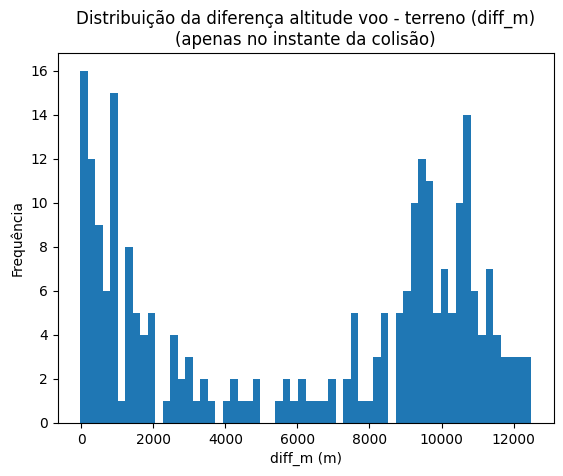

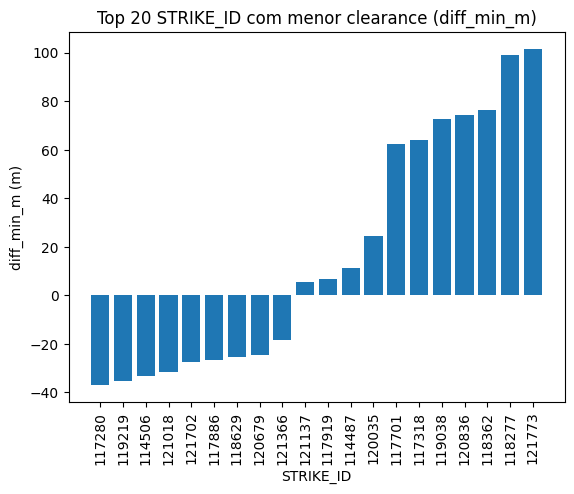

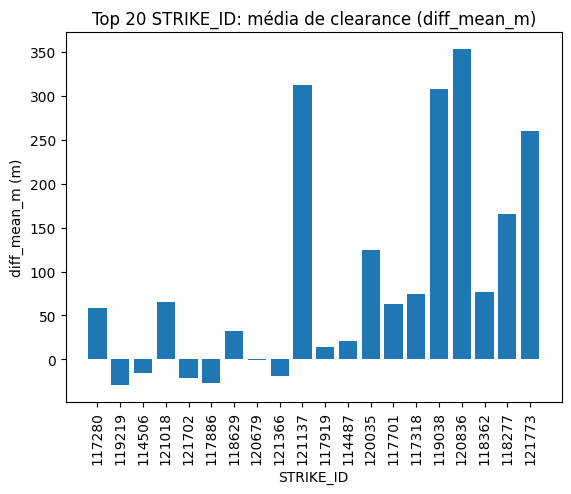

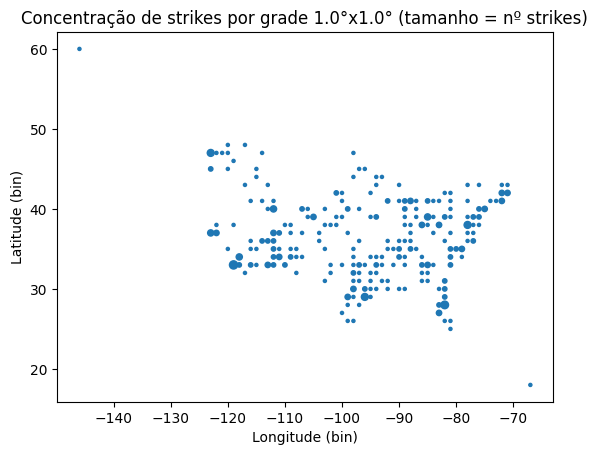

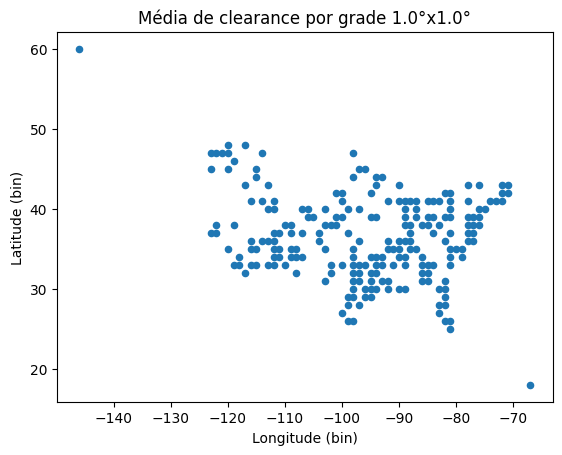

In [3]:
# --- BLOCO B: GRÁFICOS (matplotlib, sem seaborn) ---

import matplotlib.pyplot as plt

# 0) Filtrar apenas o ponto da colisão real (TIME_DIFF_SEC == 0)
lf_center = lf_valid.filter(pl.col("time_diff_sec") == 0)

# 1) Distribuição de diff_m (somente instante da colisão)
df_valid = lf_center.select(["diff_m"]).collect().to_pandas()

plt.figure()
plt.hist(df_valid["diff_m"], bins=60)
plt.title("Distribuição da diferença altitude voo - terreno (diff_m)\n(apenas no instante da colisão)")
plt.xlabel("diff_m (m)")
plt.ylabel("Frequência")
plt.show()


# 2) Média e mínimo por STRIKE_ID (top 20 mais críticos)
# Aqui está correto usar stats_strike
df_stats = stats_strike.to_pandas().sort_values("diff_min_m")

top20 = df_stats.head(20)

plt.figure()
plt.bar(top20["STRIKE_ID"].astype(str), top20["diff_min_m"])
plt.title("Top 20 STRIKE_ID com menor clearance (diff_min_m)")
plt.xlabel("STRIKE_ID")
plt.ylabel("diff_min_m (m)")
plt.xticks(rotation=90)
plt.show()

plt.figure()
plt.bar(top20["STRIKE_ID"].astype(str), top20["diff_mean_m"])
plt.title("Top 20 STRIKE_ID: média de clearance (diff_mean_m)")
plt.xlabel("STRIKE_ID")
plt.ylabel("diff_mean_m (m)")
plt.xticks(rotation=90)
plt.show()


# 3) "Mapa" por grade lat/lon
df_grid = grid.to_pandas()

plt.figure()
plt.scatter(df_grid["lon_bin"], df_grid["lat_bin"], s=df_grid["n_strikes"]*5)
plt.title(f"Concentração de strikes por grade {GRID_DEG}°x{GRID_DEG}° (tamanho = nº strikes)")
plt.xlabel("Longitude (bin)")
plt.ylabel("Latitude (bin)")
plt.show()

plt.figure()
plt.scatter(df_grid["lon_bin"], df_grid["lat_bin"], s=20)
plt.title(f"Média de clearance por grade {GRID_DEG}°x{GRID_DEG}°")
plt.xlabel("Longitude (bin)")
plt.ylabel("Latitude (bin)")
plt.show()


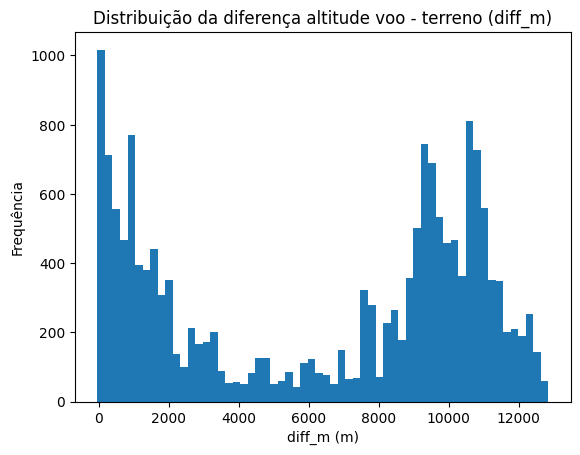

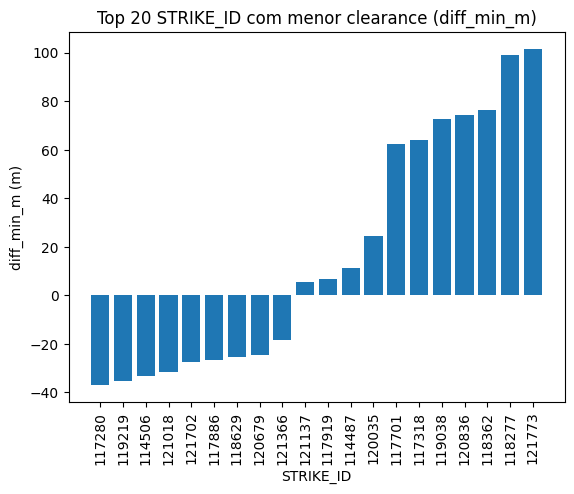

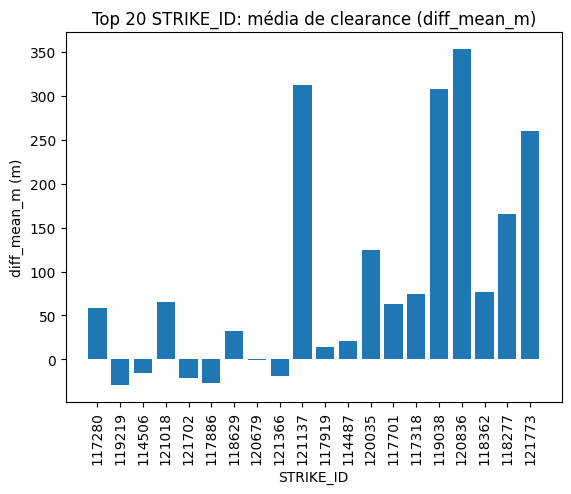

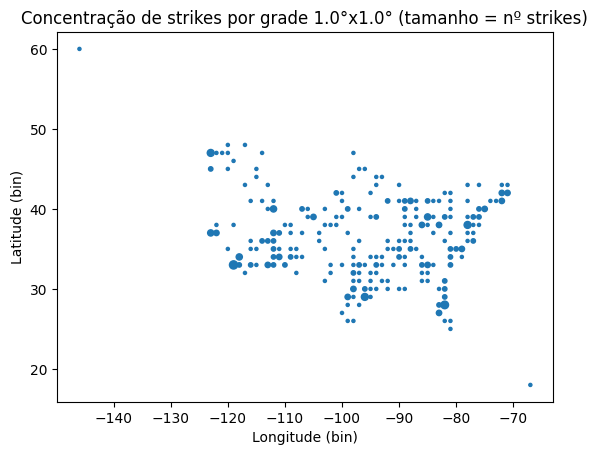

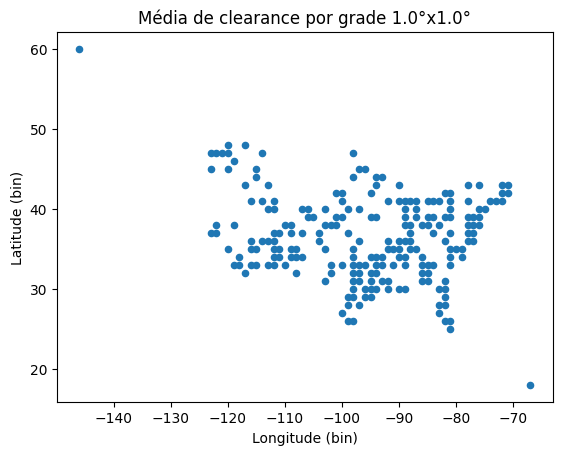

In [9]:
# --- BLOCO B: GRÁFICOS (matplotlib, sem seaborn) ---

import matplotlib.pyplot as plt

# 1) Distribuição geral de diff_m (clearance)
df_valid = lf_valid.select(["diff_m"]).collect().to_pandas()

plt.figure()
plt.hist(df_valid["diff_m"], bins=60)
plt.title("Distribuição da diferença altitude voo - terreno (diff_m)")
plt.xlabel("diff_m (m)")
plt.ylabel("Frequência")
plt.show()

# 2) Média e mínimo por STRIKE_ID (top 20 mais críticos)
df_stats = stats_strike.to_pandas().sort_values("diff_min_m")

top20 = df_stats.head(20)

plt.figure()
plt.bar(top20["STRIKE_ID"].astype(str), top20["diff_min_m"])
plt.title("Top 20 STRIKE_ID com menor clearance (diff_min_m)")
plt.xlabel("STRIKE_ID")
plt.ylabel("diff_min_m (m)")
plt.xticks(rotation=90)
plt.show()

plt.figure()
plt.bar(top20["STRIKE_ID"].astype(str), top20["diff_mean_m"])
plt.title("Top 20 STRIKE_ID: média de clearance (diff_mean_m)")
plt.xlabel("STRIKE_ID")
plt.ylabel("diff_mean_m (m)")
plt.xticks(rotation=90)
plt.show()

# 3) "Mapa" por grade lat/lon (strikes espalhados nos EUA)
df_grid = grid.to_pandas()

plt.figure()
plt.scatter(df_grid["lon_bin"], df_grid["lat_bin"], s=df_grid["n_strikes"]*5)
plt.title(f"Concentração de strikes por grade {GRID_DEG}°x{GRID_DEG}° (tamanho = nº strikes)")
plt.xlabel("Longitude (bin)")
plt.ylabel("Latitude (bin)")
plt.show()

plt.figure()
plt.scatter(df_grid["lon_bin"], df_grid["lat_bin"], s=20)
plt.title(f"Média de clearance por grade {GRID_DEG}°x{GRID_DEG}°")
plt.xlabel("Longitude (bin)")
plt.ylabel("Latitude (bin)")
# se quiser ver valor numérico depois: exporta df_grid e plota em GIS
plt.show()


Top 10 espécies: ['Barn swallow', 'Chimney swift', 'Cliff swallow', 'Horned lark', 'European starling', 'White-throated sparrow', 'Yellow-rumped warbler', 'Canada goose', 'Mourning dove', 'American kestrel']


/tmp/ipykernel_3429551/838540218.py:54: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



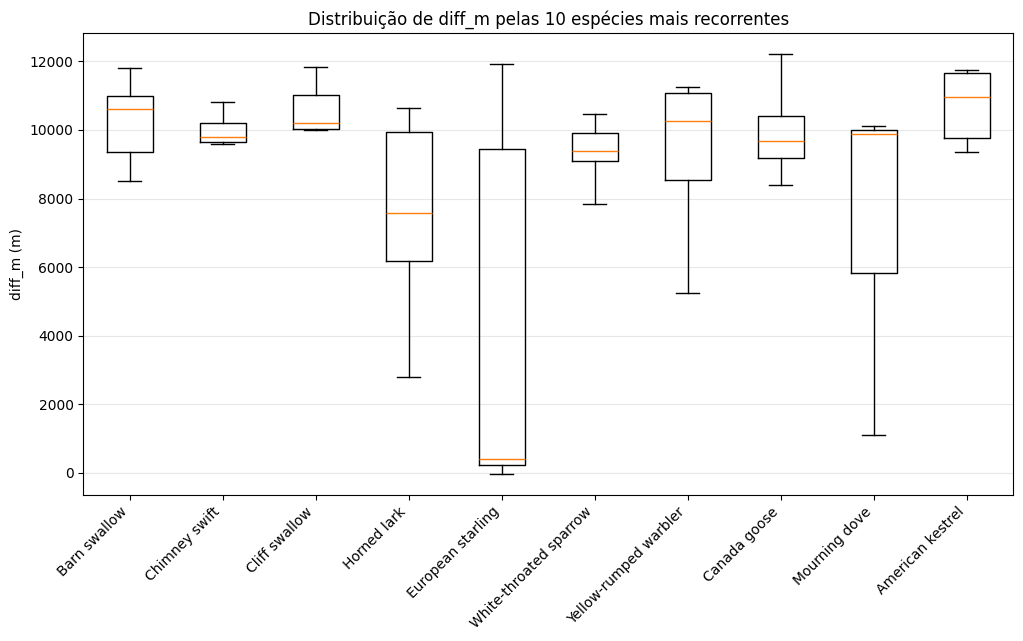

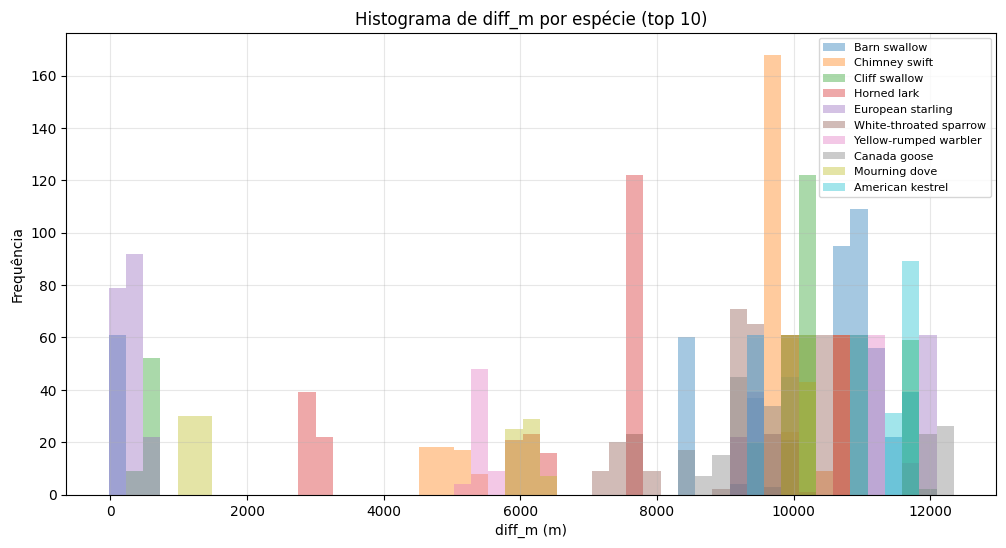

In [14]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# use seu lf já normalizado da célula anterior;
# se ainda não existir, leia como antes e renomeie colunas truncadas.

# 1) LazyFrame válido (diff_m e SPECIES)
lf_valid = (
    lf
    .filter(pl.col("diff_m").is_not_null())
    .filter(pl.col("diff_m").is_finite())
    .filter(pl.col("SPECIES").is_not_null())
)

# 2) remover "Unknown bird" (várias grafias)
lf_no_unknown = lf_valid.filter(
    ~pl.col("SPECIES").str.to_lowercase().str.contains("unknow") &
    ~pl.col("SPECIES").str.to_lowercase().str.contains("unknown")
)

# 3) top 10 espécies mais recorrentes
top10_species = (
    lf_no_unknown
    .group_by("SPECIES")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .head(10)
    .collect()
)

species_list = top10_species["SPECIES"].to_list()
print("Top 10 espécies:", species_list)

# 4) coletar dados só dessas espécies (ainda lazy até aqui)
df_top10 = (
    lf_no_unknown
    .filter(pl.col("SPECIES").is_in(species_list))
    .select(["SPECIES", "diff_m"])
    .collect()
    .to_pandas()
)

# -----------------------------
# (A) BOXPLOT por espécie
# -----------------------------
order = (top10_species
         .sort("n", descending=True)["SPECIES"]
         .to_list())

data = [df_top10.loc[df_top10["SPECIES"] == sp, "diff_m"].values for sp in order]

plt.figure(figsize=(12,6))
plt.boxplot(data, labels=order, showfliers=False)
plt.title("Distribuição de diff_m pelas 10 espécies mais recorrentes")
plt.ylabel("diff_m (m)")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3, axis="y")
plt.show()

# -----------------------------
# (B) HISTOGRAMA empilhado (opcional)
# -----------------------------
plt.figure(figsize=(12,6))

bins = np.linspace(df_top10["diff_m"].min(), df_top10["diff_m"].max(), 50)

for sp in order:
    vals = df_top10.loc[df_top10["SPECIES"] == sp, "diff_m"].values
    plt.hist(vals, bins=bins, alpha=0.4, label=sp)

plt.title("Histograma de diff_m por espécie (top 10)")
plt.xlabel("diff_m (m)")
plt.ylabel("Frequência")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()


Top 10 grupos: ['Passerine & Small Bird', 'Raptor & Owl', 'Waterfowl (Ducks, Geese, Swans)', 'Wader & Heron', 'Gull & Tern', 'Other', 'Pigeon & Dove']


/tmp/ipykernel_3429551/89291423.py:61: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



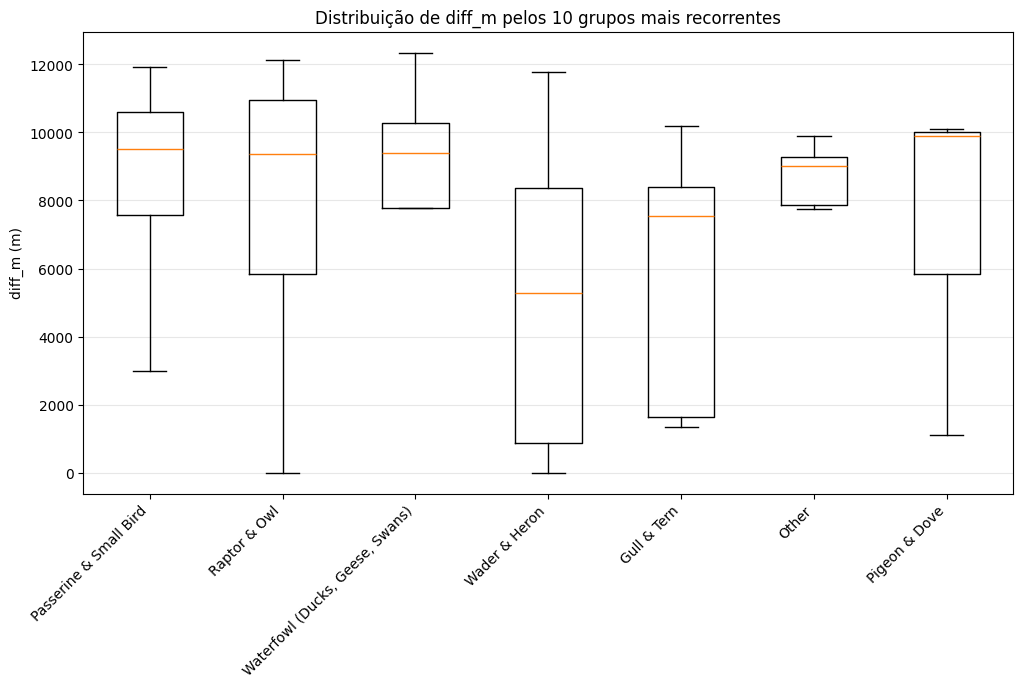

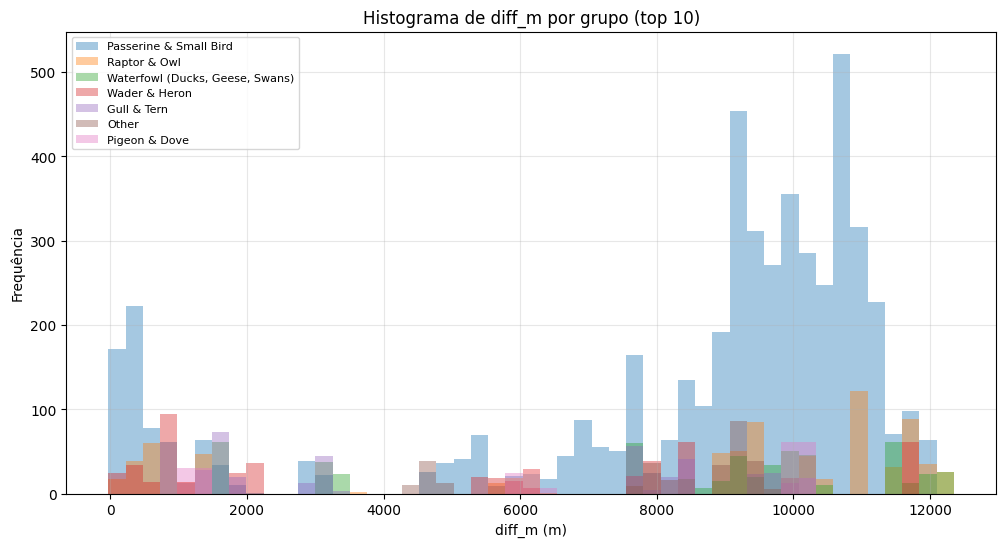

In [17]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# coluna correta no seu CSV/LazyFrame:
GROUP_COL = "species_group"

# 1) LazyFrame válido (diff_m + grupo + especie)
lf_valid = (
    lf
    .filter(pl.col("diff_m").is_not_null())
    .filter(pl.col("diff_m").is_finite())
    .filter(pl.col("SPECIES").is_not_null())
    .filter(pl.col(GROUP_COL).is_not_null())
)

# 2) remover Unknown bird (texto na espécie) + grupo Unknown
lf_no_unknown = (
    lf_valid
    .filter(
        ~pl.col("SPECIES").str.to_lowercase().str.contains("unknow") &
        ~pl.col("SPECIES").str.to_lowercase().str.contains("unknown")
    )
    .filter(~pl.col(GROUP_COL).str.to_lowercase().eq("unknown"))
)

# 3) top 10 GRUPOS mais recorrentes
top10_groups = (
    lf_no_unknown
    .group_by(GROUP_COL)
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
    .head(10)
    .collect()
)

group_list = top10_groups[GROUP_COL].to_list()
print("Top 10 grupos:", group_list)

# 4) coletar dados só desses grupos
df_top10 = (
    lf_no_unknown
    .filter(pl.col(GROUP_COL).is_in(group_list))
    .select([GROUP_COL, "diff_m"])
    .collect()
    .to_pandas()
)

# -----------------------------
# (A) BOXPLOT por grupo
# -----------------------------
order = (
    top10_groups
    .sort("n", descending=True)[GROUP_COL]
    .to_list()
)

data = [df_top10.loc[df_top10[GROUP_COL] == g, "diff_m"].values for g in order]

plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=order, showfliers=False)
plt.title("Distribuição de diff_m pelos 10 grupos mais recorrentes")
plt.ylabel("diff_m (m)")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3, axis="y")
plt.show()

# -----------------------------
# (B) HISTOGRAMA empilhado por grupo (opcional)
# -----------------------------
plt.figure(figsize=(12, 6))

bins = np.linspace(df_top10["diff_m"].min(), df_top10["diff_m"].max(), 50)

for g in order:
    vals = df_top10.loc[df_top10[GROUP_COL] == g, "diff_m"].values
    plt.hist(vals, bins=bins, alpha=0.4, label=g)

plt.title("Histograma de diff_m por grupo (top 10)")
plt.xlabel("diff_m (m)")
plt.ylabel("Frequência")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()
